## 03 — Pitch Distribution EDA

Visual exploration of how pitch selection varies across game contexts using June 2024 Statcast data enriched with 2023 Fangraph pitcher and batter statistics.

**Sections:**
1. Target Distribution — overall pitch type frequency and how it splits by pitcher handedness
2. Count-Situation Analysis — how balls and strikes shift pitch selection
3. Handedness Matchup — pitch mix differences across the four pitcher × batter handedness combinations
4. Game Context Features — pitch number, times through the order, score differential, inning
5. Prior-Year Arsenal Usage — how well prior-year `n_*` columns predict actual 2024 usage

See **02_data_quality** for the full column-level data quality audit. See **04_feature_importance_ml** for MI and PCA-based importance scoring.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
import pybaseball
from pybaseball import (
    cache,
    statcast,
    statcast_pitcher_pitch_arsenal,
    statcast_pitcher_arsenal_stats,
    statcast_batter_expected_stats,
    statcast_batter_pitch_arsenal,
)
sys.path.append(str(Path("..").resolve()))
from utils.features.feature_names import (
    TRAINABLE_COLUMNS,
    LABEL_COLUMN,
)

DATA_DIR = Path("..") / "data" / "cache"
DATA_DIR.mkdir(parents=True, exist_ok=True)
cache.config.cache_directory = str(DATA_DIR.resolve())
cache.config.save()
cache.enable()

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

### Canonical pitch type codes (mirrors _PITCH_TYPES in feature_names.py)
PITCH_TYPES = ["FF", "SI", "FC", "SL", "CH", "CU", "FS", "KN", "ST", "SV"]

print("pybaseball :", pybaseball.__version__)
print("pandas     :", pd.__version__)
print("cache dir  :", cache.config.cache_directory)

pybaseball : 2.2.7
pandas     : 2.2.3
cache dir  : C:\Users\ihuang\Documents\python projects\MLB-Pitch-Predictor\data\cache


In [2]:
SEASON = 2024
PRIOR  = SEASON - 1

df = statcast("2024-06-01", "2024-06-30")
print(f"Raw Statcast shape: {df.shape}")

This is a large query, it may take a moment to complete


100%|██████████| 30/30 [00:00<00:00, 79.54it/s]


Raw Statcast shape: (116355, 118)


In [3]:
### Pitcher pitch-usage % (prior year)
pit_usage = statcast_pitcher_pitch_arsenal(PRIOR, arsenal_type="n_")
pit_usage_w = pit_usage.rename(columns={"pitcher_id": "pitcher"})  # col is already 'pitcher', no-op

### Pitcher per-pitch outcome stats (prior year)
pit_outcomes = statcast_pitcher_arsenal_stats(PRIOR, minPA=25)
pit_out_stat_cols = [
    c for c in pit_outcomes.columns
    if c not in ["last_name, first_name", "player_id", "team_name_alt", "pitch_type", "pitch_name"]
]
pit_outcomes_w = pit_outcomes.pivot_table(
    index="player_id", columns="pitch_type", values=pit_out_stat_cols, aggfunc="first"
)
pit_outcomes_w.columns = [f"{stat}_{pt}" for stat, pt in pit_outcomes_w.columns]
pit_outcomes_w = pit_outcomes_w.reset_index().rename(columns={"player_id": "pitcher"})

### Batter expected stats (prior year)
bat_xstats = statcast_batter_expected_stats(PRIOR)
bat_xstats_w = bat_xstats.rename(columns={"player_id": "batter"}).drop(
    columns=["last_name, first_name", "year"], errors="ignore"
)

### Batter vs pitch-type stats pivoted wide (prior year)
bat_vs_pitch = statcast_batter_pitch_arsenal(PRIOR, minPA=25)
bat_vs_stat_cols = [
    c for c in bat_vs_pitch.columns
    if c not in ["last_name, first_name", "player_id", "team_name_alt", "pitch_type", "pitch_name"]
]
bat_vs_pitch_w = bat_vs_pitch.pivot_table(
    index="player_id", columns="pitch_type", values=bat_vs_stat_cols, aggfunc="first"
)
bat_vs_pitch_w.columns = [f"bat_{stat}_{pt}" for stat, pt in bat_vs_pitch_w.columns]
bat_vs_pitch_w = bat_vs_pitch_w.reset_index().rename(columns={"player_id": "batter"})

### Merge all enrichment onto the pitch-level frame
df_enr = (
    df
    .merge(pit_usage_w,    on="pitcher", how="left", suffixes=("", "_pu"))
    .merge(pit_outcomes_w, on="pitcher", how="left", suffixes=("", "_po"))
    .merge(bat_xstats_w,   on="batter",  how="left", suffixes=("", "_bx"))
    .merge(bat_vs_pitch_w, on="batter",  how="left", suffixes=("", "_bv"))
)

print(f"Raw shape     : {df.shape}")
print(f"Enriched shape: {df_enr.shape}")
if "n_ff" in df_enr.columns:
    print(f"Pitcher arsenal coverage (n_ff non-null): {df_enr['n_ff'].notna().mean():.1%}")

Raw shape     : (116355, 118)
Enriched shape: (116355, 410)
Pitcher arsenal coverage (n_ff non-null): 75.0%


In [4]:
available    = [c for c in TRAINABLE_COLUMNS if c in df_enr.columns]
missing_cols = [c for c in TRAINABLE_COLUMNS if c not in df_enr.columns]

model_df = df_enr[available + [LABEL_COLUMN]].copy()
model_df = model_df[model_df[LABEL_COLUMN].isin(PITCH_TYPES)].reset_index(drop=True)

print(f"model_df shape          : {model_df.shape}")
print(f"TRAINABLE_COLUMNS total : {len(TRAINABLE_COLUMNS)}")
print(f"Found in enriched frame : {len(available)}")
if missing_cols:
    preview = missing_cols[:5]
    ellipsis = "..." if len(missing_cols) > 5 else ""
    print(f"Missing ({len(missing_cols)})            : {preview}{ellipsis}")
print(f"\nPitch type distribution:\n{model_df[LABEL_COLUMN].value_counts()}")

model_df shape          : (114080, 323)
TRAINABLE_COLUMNS total : 352
Found in enriched frame : 322
Missing (30)            : ['bat_run_value_per_100_KN', 'bat_run_value_per_100_SV', 'bat_run_value_KN', 'bat_run_value_SV', 'bat_pitches_KN']...

Pitch type distribution:
pitch_type
FF    37126
SI    18600
SL    16954
CH    11444
FC     9449
ST     8264
CU     7663
FS     3747
SV      563
KN      270
Name: count, dtype: int64


---
## Section 1 — Target Distribution

Understand class imbalance and how pitch mix varies by pitcher handedness before any feature work.

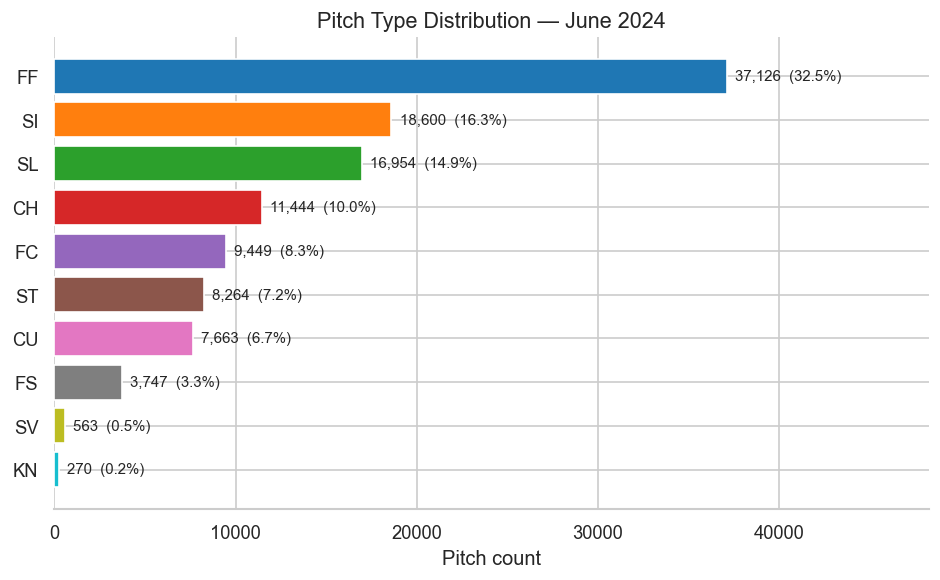

In [5]:
### Visual 1 — Overall pitch type frequency
counts = model_df[LABEL_COLUMN].value_counts()
total  = counts.sum()

fig, ax = plt.subplots(figsize=(8, 5))
palette = sns.color_palette("tab10", len(counts))
bars = ax.barh(counts.index, counts.values, color=palette)

for bar, cnt in zip(bars, counts.values):
    ax.text(
        bar.get_width() + total * 0.004,
        bar.get_y() + bar.get_height() / 2,
        f"{cnt:,}  ({cnt / total:.1%})",
        va="center", fontsize=9,
    )

ax.set_xlabel("Pitch count")
ax.set_title("Pitch Type Distribution — June 2024", fontsize=13)
ax.set_xlim(0, counts.max() * 1.30)
ax.invert_yaxis()
sns.despine(left=True, bottom=False)
plt.tight_layout()
plt.show()

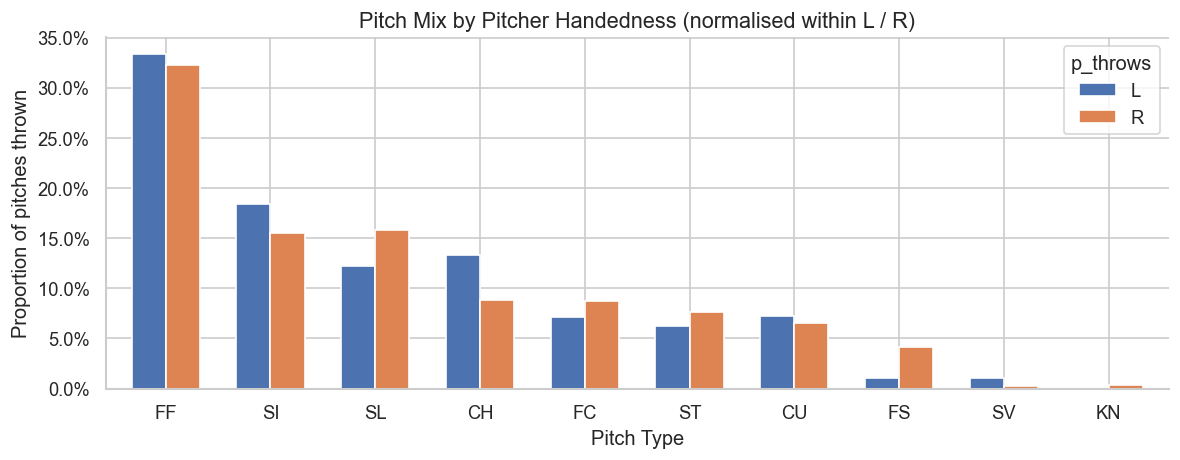

In [6]:
### Visual 2 — Pitch mix by pitcher handedness (normalised within L / R)
hand_mix = (
    model_df.groupby(["p_throws", LABEL_COLUMN])
    .size()
    .unstack(fill_value=0)
    .apply(lambda row: row / row.sum(), axis=1)
)
### Reorder columns by overall frequency so bars are visually consistent
hand_mix = hand_mix.reindex(columns=counts.index, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
hand_mix.T.plot(kind="bar", ax=ax, color=["#4c72b0", "#dd8452"], width=0.65, edgecolor="white")
ax.set_xlabel("Pitch Type")
ax.set_ylabel("Proportion of pitches thrown")
ax.set_title("Pitch Mix by Pitcher Handedness (normalised within L / R)", fontsize=13)
ax.legend(title="p_throws", loc="upper right")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

In [7]:
### Visual 3 — Data prep: pitch usage normalised within each (p_throws × stand) matchup
matchup_mix = (
    model_df.groupby(["p_throws", "stand", LABEL_COLUMN])
    .size()
    .unstack(fill_value=0)
    .apply(lambda row: row / row.sum(), axis=1)   # normalise within matchup
)
matchup_mix = matchup_mix.reindex(columns=counts.index, fill_value=0)
matchup_mix = matchup_mix.reset_index()

### Sanity check
print(matchup_mix[["p_throws", "stand"]].value_counts().sort_index())
print(matchup_mix.head())

p_throws  stand
L         L        1
          R        1
R         L        1
          R        1
Name: count, dtype: int64
pitch_type p_throws stand        FF        SI        SL        CH        FC  \
0                 L     L  0.290670  0.253047  0.183544  0.026371  0.075012   
1                 L     R  0.349960  0.157013  0.099267  0.173863  0.069277   
2                 R     L  0.355041  0.105944  0.109171  0.138723  0.094599   
3                 R     R  0.293530  0.199229  0.201790  0.043331  0.080793   

pitch_type        ST        CU        FS        SV        KN  
0           0.105720  0.046296  0.003165  0.016174  0.000000  
1           0.045901  0.082104  0.013677  0.008090  0.000849  
2           0.047043  0.086251  0.056519  0.002791  0.003918  
3           0.101938  0.046754  0.027354  0.003059  0.002221  


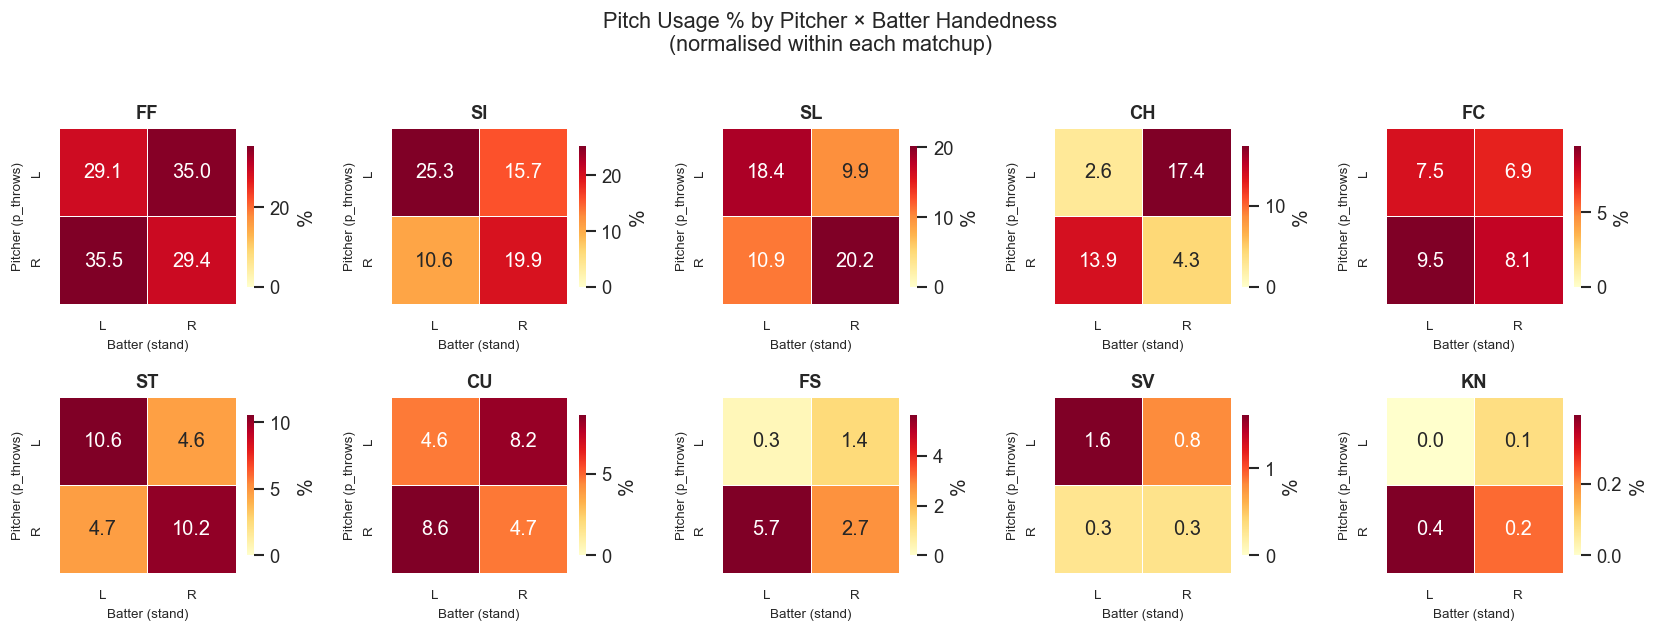

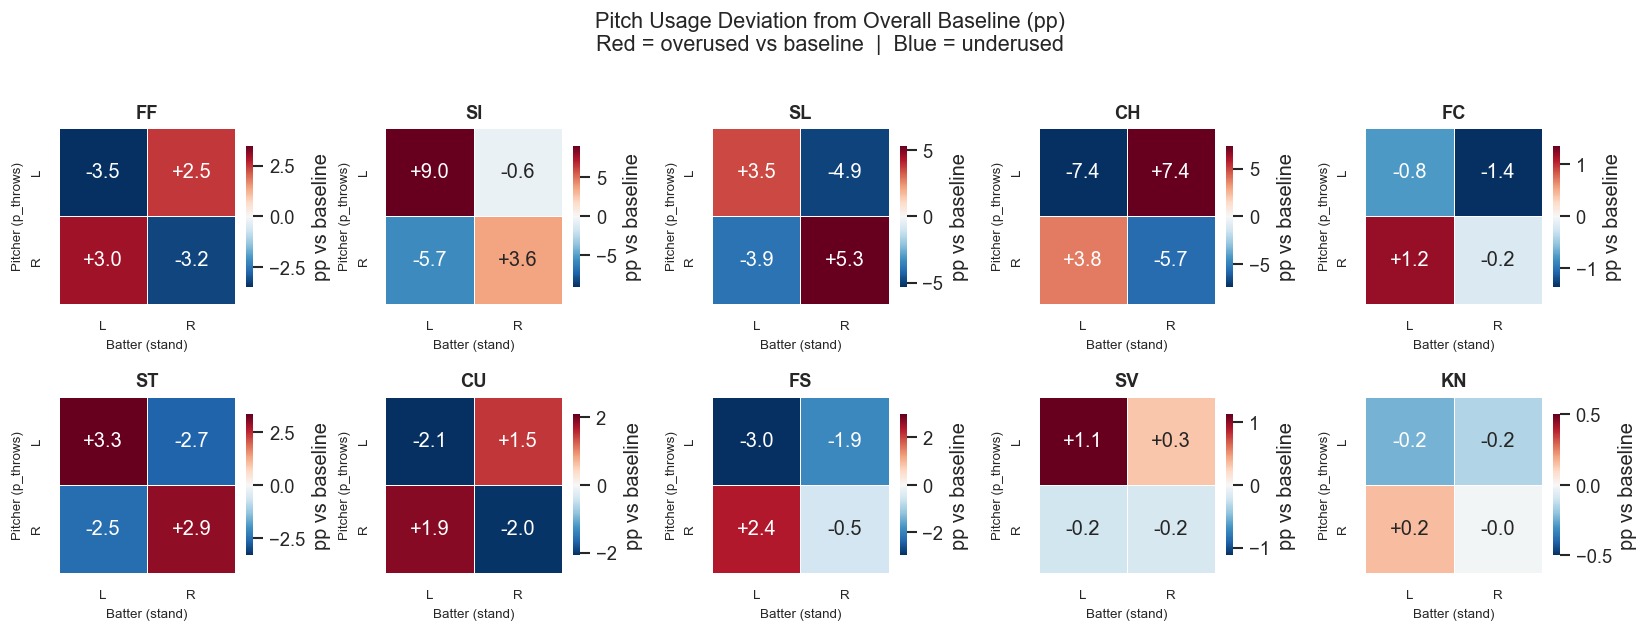

In [8]:
import math

pitch_types_plot = [pt for pt in counts.index if pt in matchup_mix.columns]
overall_rate = counts / counts.sum()   # used for delta layer

### Figure layout
ncols = 5
nrows = math.ceil(len(pitch_types_plot) / ncols)

### Primary heatmap — absolute normalised usage %
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 2.8, nrows * 2.6))
axes = axes.flatten()

for ax, pt in zip(axes, pitch_types_plot):
    matrix = matchup_mix.pivot(index="p_throws", columns="stand", values=pt)
    matrix = matrix.reindex(index=["L", "R"], columns=["L", "R"]) * 100
    sns.heatmap(
        matrix, ax=ax,
        annot=True, fmt=".1f", cmap="YlOrRd",
        vmin=0, linewidths=0.5,
        cbar_kws={"label": "%", "shrink": 0.8},
    )
    ax.set_title(pt, fontweight="bold", fontsize=11)
    ax.set_xlabel("Batter (stand)", fontsize=8)
    ax.set_ylabel("Pitcher (p_throws)", fontsize=8)
    ax.tick_params(labelsize=8)

### Hide any unused subplot slots
for ax in axes[len(pitch_types_plot):]:
    ax.set_visible(False)

fig.suptitle(
    "Pitch Usage % by Pitcher × Batter Handedness\n"
    "(normalised within each matchup)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

### Delta heatmap — usage relative to each pitch type's overall baseline
fig2, axes2 = plt.subplots(nrows, ncols, figsize=(ncols * 2.8, nrows * 2.6))
axes2 = axes2.flatten()

for ax, pt in zip(axes2, pitch_types_plot):
    matrix = matchup_mix.pivot(index="p_throws", columns="stand", values=pt)
    matrix = matrix.reindex(index=["L", "R"], columns=["L", "R"]) * 100
    delta = matrix - (overall_rate[pt] * 100)
    abs_max = max(abs(delta.values.min()), abs(delta.values.max()), 0.5)
    sns.heatmap(
        delta, ax=ax,
        annot=True, fmt="+.1f", cmap="RdBu_r",
        center=0, vmin=-abs_max, vmax=abs_max,
        linewidths=0.5,
        cbar_kws={"label": "pp vs baseline", "shrink": 0.8},
    )
    ax.set_title(pt, fontweight="bold", fontsize=11)
    ax.set_xlabel("Batter (stand)", fontsize=8)
    ax.set_ylabel("Pitcher (p_throws)", fontsize=8)
    ax.tick_params(labelsize=8)

for ax in axes2[len(pitch_types_plot):]:
    ax.set_visible(False)

fig2.suptitle(
    "Pitch Usage Deviation from Overall Baseline (pp)\n"
    "Red = overused vs baseline  |  Blue = underused",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

---
## Section 2 — Count-Situation Analysis (balls × strikes)

**Hypothesis:** `balls` and `strikes` are among the strongest pure game-state predictors of pitch type.

- Hitter-friendly counts (3-0, 3-1) → pitchers throw more fastballs to avoid walking the batter
- Pitcher-friendly counts (0-2, 1-2) → pitchers lean on offspeed to try to expand the zone

**Visual 1** — Heatmap grid: one 4×3 heatmap per pitch type, cells show usage rate by count  
**Visual 2** — Stacked bar: full pitch mix across all 12 count situations, sorted by volume

In [11]:
### Compute per-count pitch type proportions
count_pitch = (
    model_df.groupby(["balls", "strikes", LABEL_COLUMN])
    .size()
    .reset_index(name="n")
)
count_totals = count_pitch.groupby(["balls", "strikes"])["n"].transform("sum")
count_pitch["proportion"] = count_pitch["n"] / count_totals

print("Total pitches per count situation:")
vol = model_df.groupby(["balls", "strikes"]).size().unstack(fill_value=0)
vol.index.name   = "balls \\ strikes"
vol.columns.name = "strikes"
print(vol)

Total pitches per count situation:
strikes              0      1      2
balls \ strikes                     
0                29438  15034   7835
1                11019  11479  11102
2                 3653   5913   9458
3                 1040   2382   5727


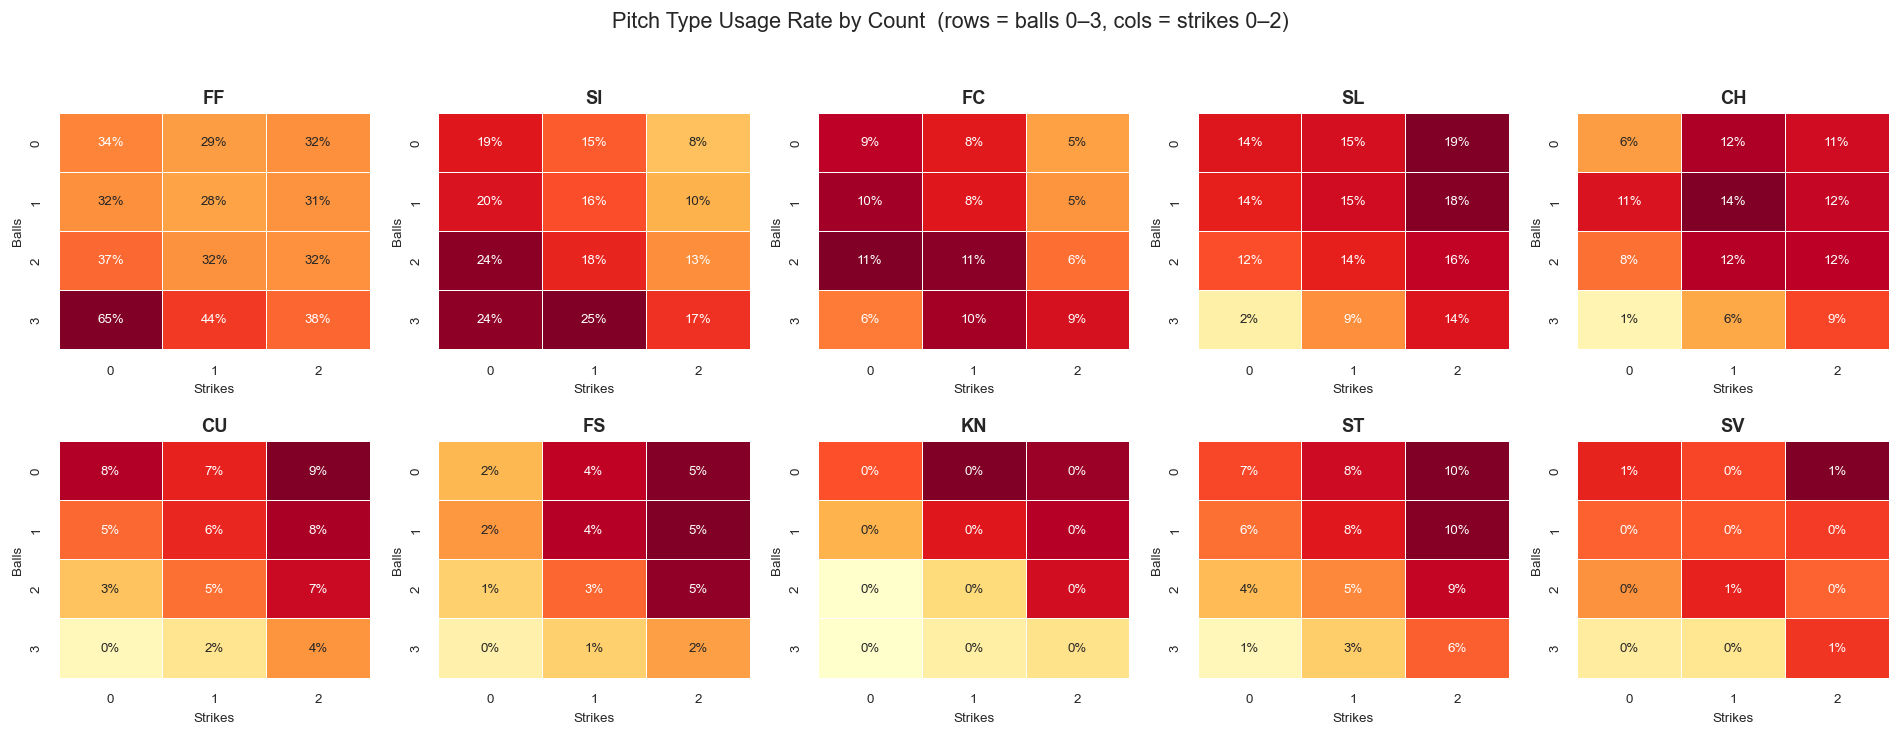

In [12]:
### Visual 1 — Heatmap grid: one subplot per pitch type
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes_flat  = axes.flatten()

for idx, pt in enumerate(PITCH_TYPES):
    ax      = axes_flat[idx]
    pt_data = count_pitch[count_pitch[LABEL_COLUMN] == pt]
    hm = (
        pt_data
        .pivot_table(index="balls", columns="strikes", values="proportion", fill_value=0.0)
        .reindex(index=[0, 1, 2, 3], columns=[0, 1, 2], fill_value=0.0)
    )
    sns.heatmap(
        hm,
        ax=ax,
        cmap="YlOrRd",
        annot=True,
        fmt=".0%",
        vmin=0,
        cbar=False,
        linewidths=0.4,
        linecolor="white",
        annot_kws={"size": 8},
    )
    ax.set_title(pt, fontsize=11, fontweight="bold")
    ax.set_xlabel("Strikes", fontsize=8)
    ax.set_ylabel("Balls",   fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(
    "Pitch Type Usage Rate by Count  (rows = balls 0–3, cols = strikes 0–2)",
    y=1.02, fontsize=13,
)
plt.tight_layout()
plt.show()

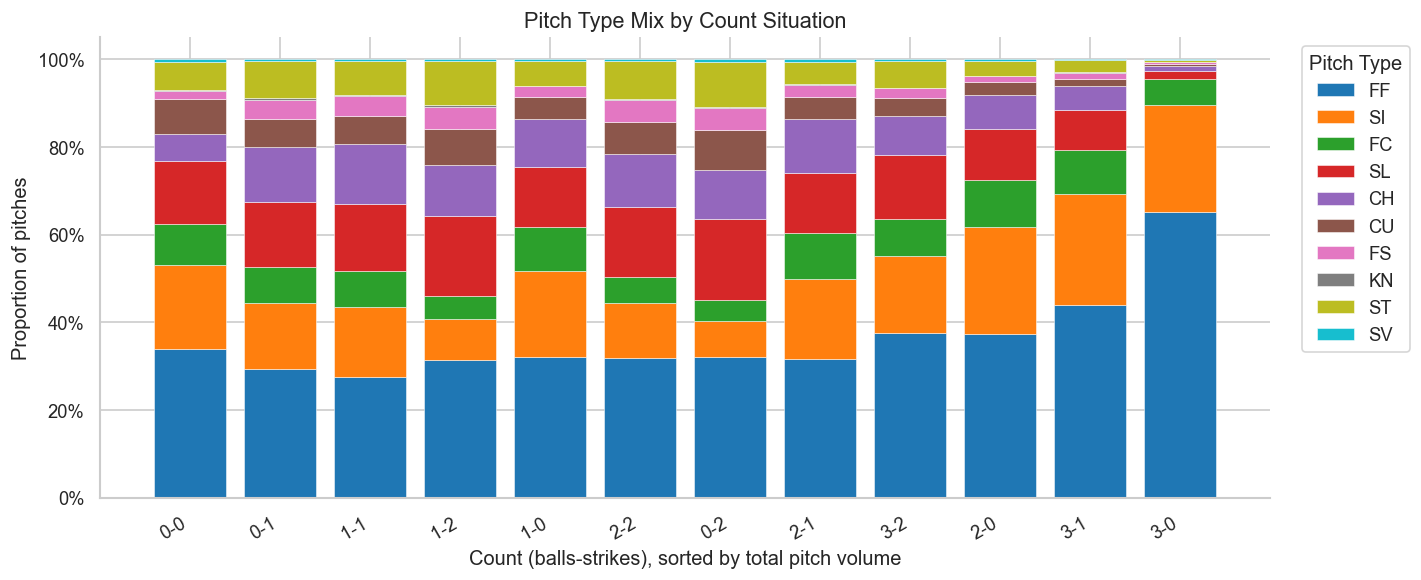

In [13]:
### Visual 2 — Stacked bar: full pitch mix across all count situations
count_wide = (
    count_pitch
    .set_index(["balls", "strikes", LABEL_COLUMN])["proportion"]
    .unstack(LABEL_COLUMN)
    .fillna(0.0)
    .reset_index()
)

### Attach total volume for sorting, then sort busiest counts first
vol_df     = model_df.groupby(["balls", "strikes"]).size().reset_index(name="total")
count_wide = count_wide.merge(vol_df, on=["balls", "strikes"])
count_wide = count_wide.sort_values("total", ascending=False).reset_index(drop=True)
count_wide["count_label"] = count_wide["balls"].astype(str) + "-" + count_wide["strikes"].astype(str)

pt_in_data = [pt for pt in PITCH_TYPES if pt in count_wide.columns]
palette    = sns.color_palette("tab10", len(pt_in_data))

fig, ax = plt.subplots(figsize=(12, 5))
bottom  = np.zeros(len(count_wide))
for i, pt in enumerate(pt_in_data):
    ax.bar(
        count_wide["count_label"],
        count_wide[pt],
        bottom=bottom,
        label=pt,
        color=palette[i],
        width=0.8,
        edgecolor="white",
        linewidth=0.3,
    )
    bottom += count_wide[pt].values

ax.set_xlabel("Count (balls-strikes), sorted by total pitch volume")
ax.set_ylabel("Proportion of pitches")
ax.set_title("Pitch Type Mix by Count Situation", fontsize=13)
ax.legend(title="Pitch Type", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=30, ha="right")
sns.despine()
plt.tight_layout()
plt.show()

---
## Section 2 — Handedness Matchup (stand × p_throws)

**Hypothesis:** The four matchup combinations (RHP vs RHB, RHP vs LHB, LHP vs RHB, LHP vs LHB) produce meaningfully different pitch mixes.

- Same-side matchups favour breaking balls that bend away from the batter (e.g. SL from RHP vs RHB)
- Opposite-side matchups shift toward fastballs and change-ups

**Visual 1** — 2×2 facet grid: one stacked bar per matchup showing normalised pitch mix  
**Visual 2** — Grouped line chart: for each pitch type, how its usage rate shifts across the 4 matchups

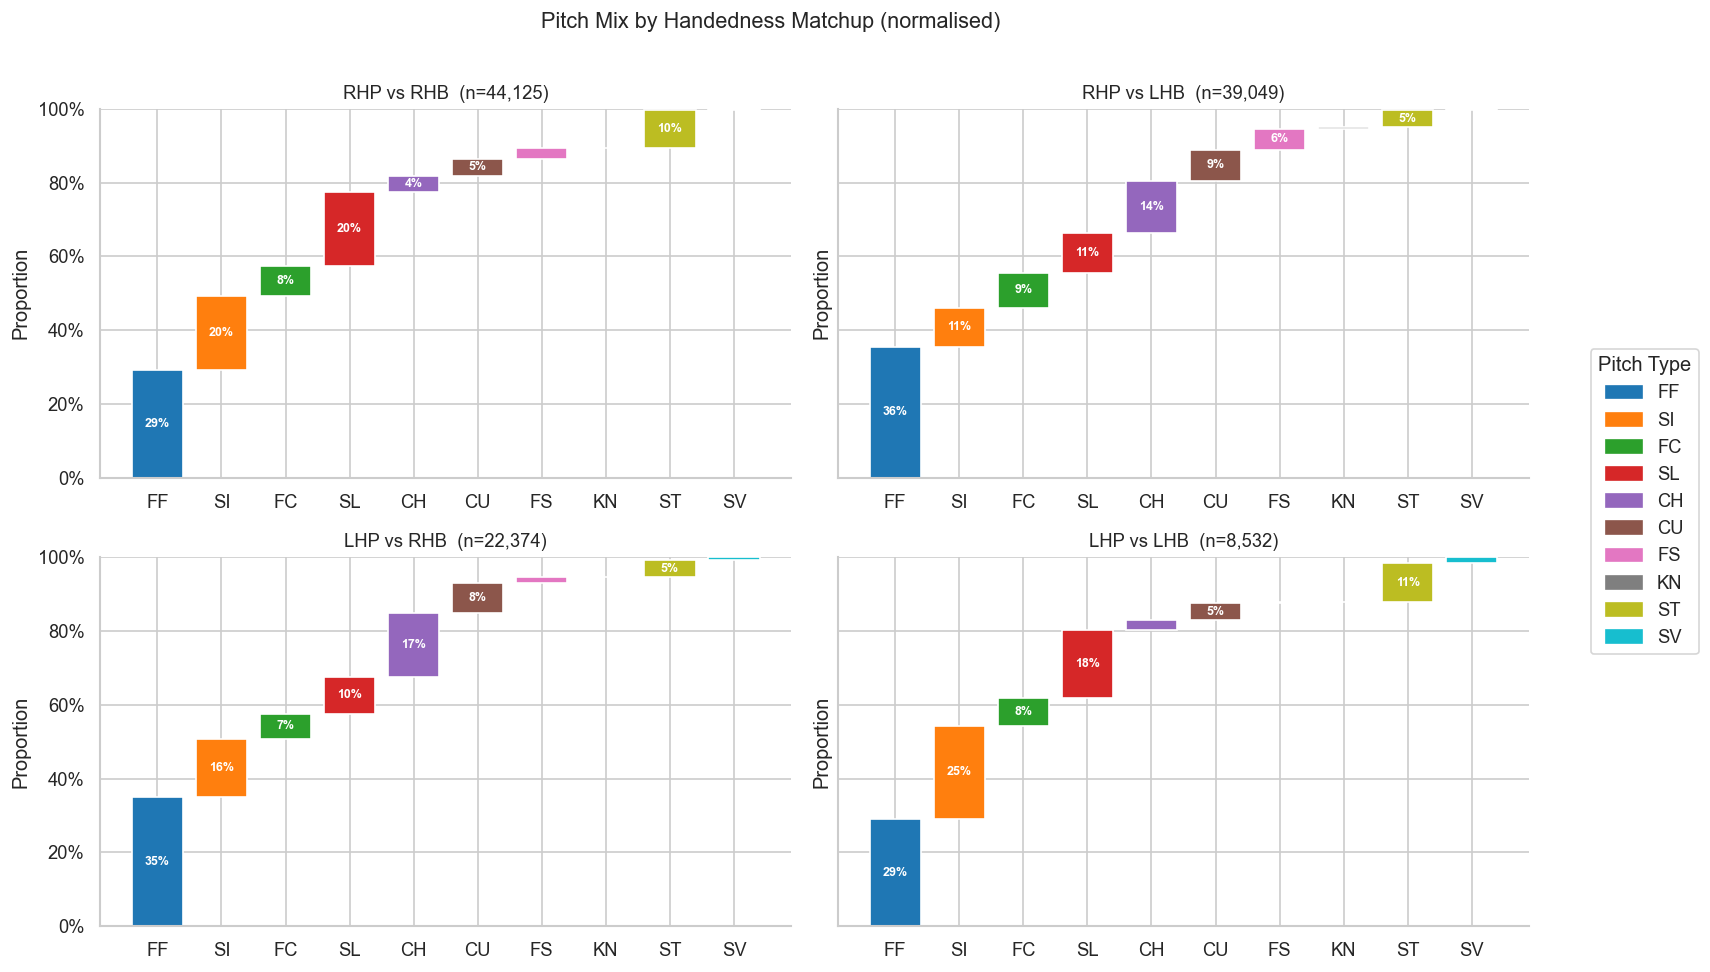

In [14]:
### Visual 1 — 2×2 facet: stacked bar per matchup combination
MATCHUP_ORDER = ["RHP vs RHB", "RHP vs LHB", "LHP vs RHB", "LHP vs LHB"]

model_df["matchup"] = model_df["p_throws"] + "HP vs " + model_df["stand"] + "HB"

matchup_mix = (
    model_df.groupby(["matchup", LABEL_COLUMN])
    .size()
    .unstack(fill_value=0)
    .apply(lambda row: row / row.sum(), axis=1)
)
### Align pitch type order and matchup order
pt_order = [pt for pt in PITCH_TYPES if pt in matchup_mix.columns]
matchup_mix = matchup_mix.reindex(index=MATCHUP_ORDER, columns=pt_order, fill_value=0)

palette = sns.color_palette("tab10", len(pt_order))

fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=True)
axes_flat = axes.flatten()

for ax, matchup in zip(axes_flat, MATCHUP_ORDER):
    row    = matchup_mix.loc[matchup]
    bottom = 0.0
    for i, pt in enumerate(pt_order):
        ax.bar(pt, row[pt], bottom=bottom, color=palette[i], label=pt, width=0.8, edgecolor="white")
        if row[pt] > 0.03:
            ax.text(
                pt, bottom + row[pt] / 2,
                f"{row[pt]:.0%}", ha="center", va="center",
                fontsize=7.5, color="white", fontweight="bold",
            )
        bottom += row[pt]
    n_pitches = model_df[model_df["matchup"] == matchup].shape[0]
    ax.set_title(f"{matchup}  (n={n_pitches:,})", fontsize=11)
    ax.set_ylabel("Proportion")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    ax.set_ylim(0, 1.0)
    sns.despine(ax=ax)

handles = [plt.Rectangle((0, 0), 1, 1, color=palette[i]) for i, _ in enumerate(pt_order)]
fig.legend(handles, pt_order, title="Pitch Type", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.suptitle("Pitch Mix by Handedness Matchup (normalised)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

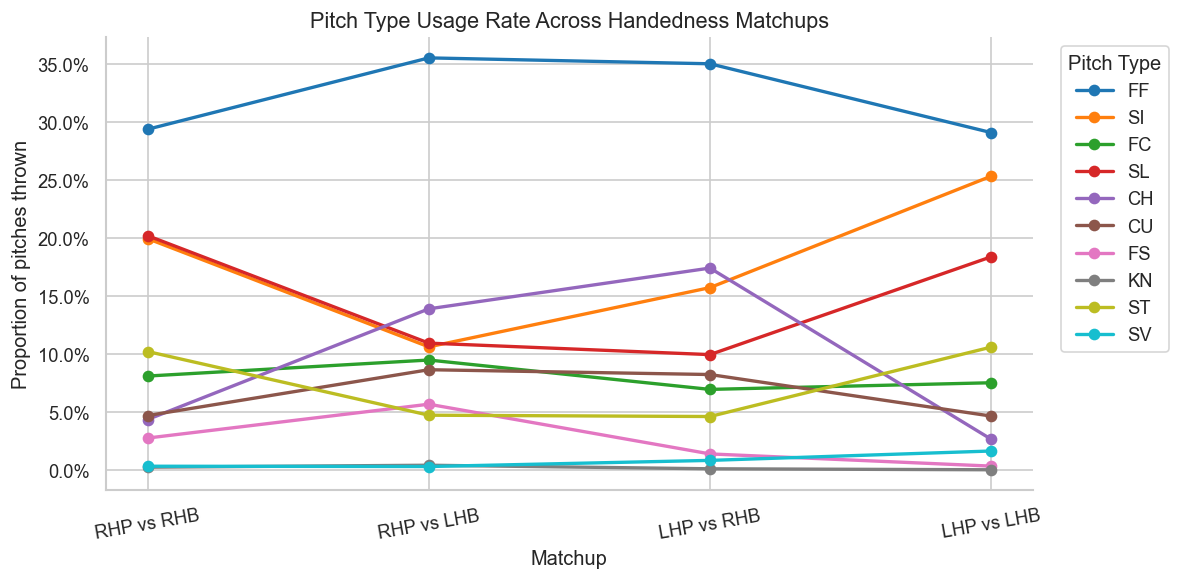

In [15]:
### Visual 2 — Line chart: how each pitch type's usage shifts across matchups
fig, ax = plt.subplots(figsize=(10, 5))

for i, pt in enumerate(pt_order):
    values = matchup_mix[pt].reindex(MATCHUP_ORDER).values
    ax.plot(MATCHUP_ORDER, values, marker="o", label=pt, color=palette[i], linewidth=2)

ax.set_xlabel("Matchup")
ax.set_ylabel("Proportion of pitches thrown")
ax.set_title("Pitch Type Usage Rate Across Handedness Matchups", fontsize=13)
ax.legend(title="Pitch Type", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.xticks(rotation=10)
sns.despine()
plt.tight_layout()
plt.show()

---
## Section 2 — Game Context Features

Four pre-pitch game-state features that may shift pitch selection:

| Feature | Hypothesis |
|---|---|
| `pitch_number` | Pitchers sequence predictably — offspeed increases as the at-bat deepens |
| `n_thruorder_pitcher` | Batters have seen the pitcher's stuff; pitch mix may evolve the 2nd/3rd time through |
| `bat_score_diff` | Large deficits (down 4+) → pitchers throw more fastballs; big leads → can mix freely |
| `inning` | Starters vs relievers have different arsenals; late innings may bring harder throwers |

Each visual shows the normalised pitch mix, making it easy to spot which pitch types shift.

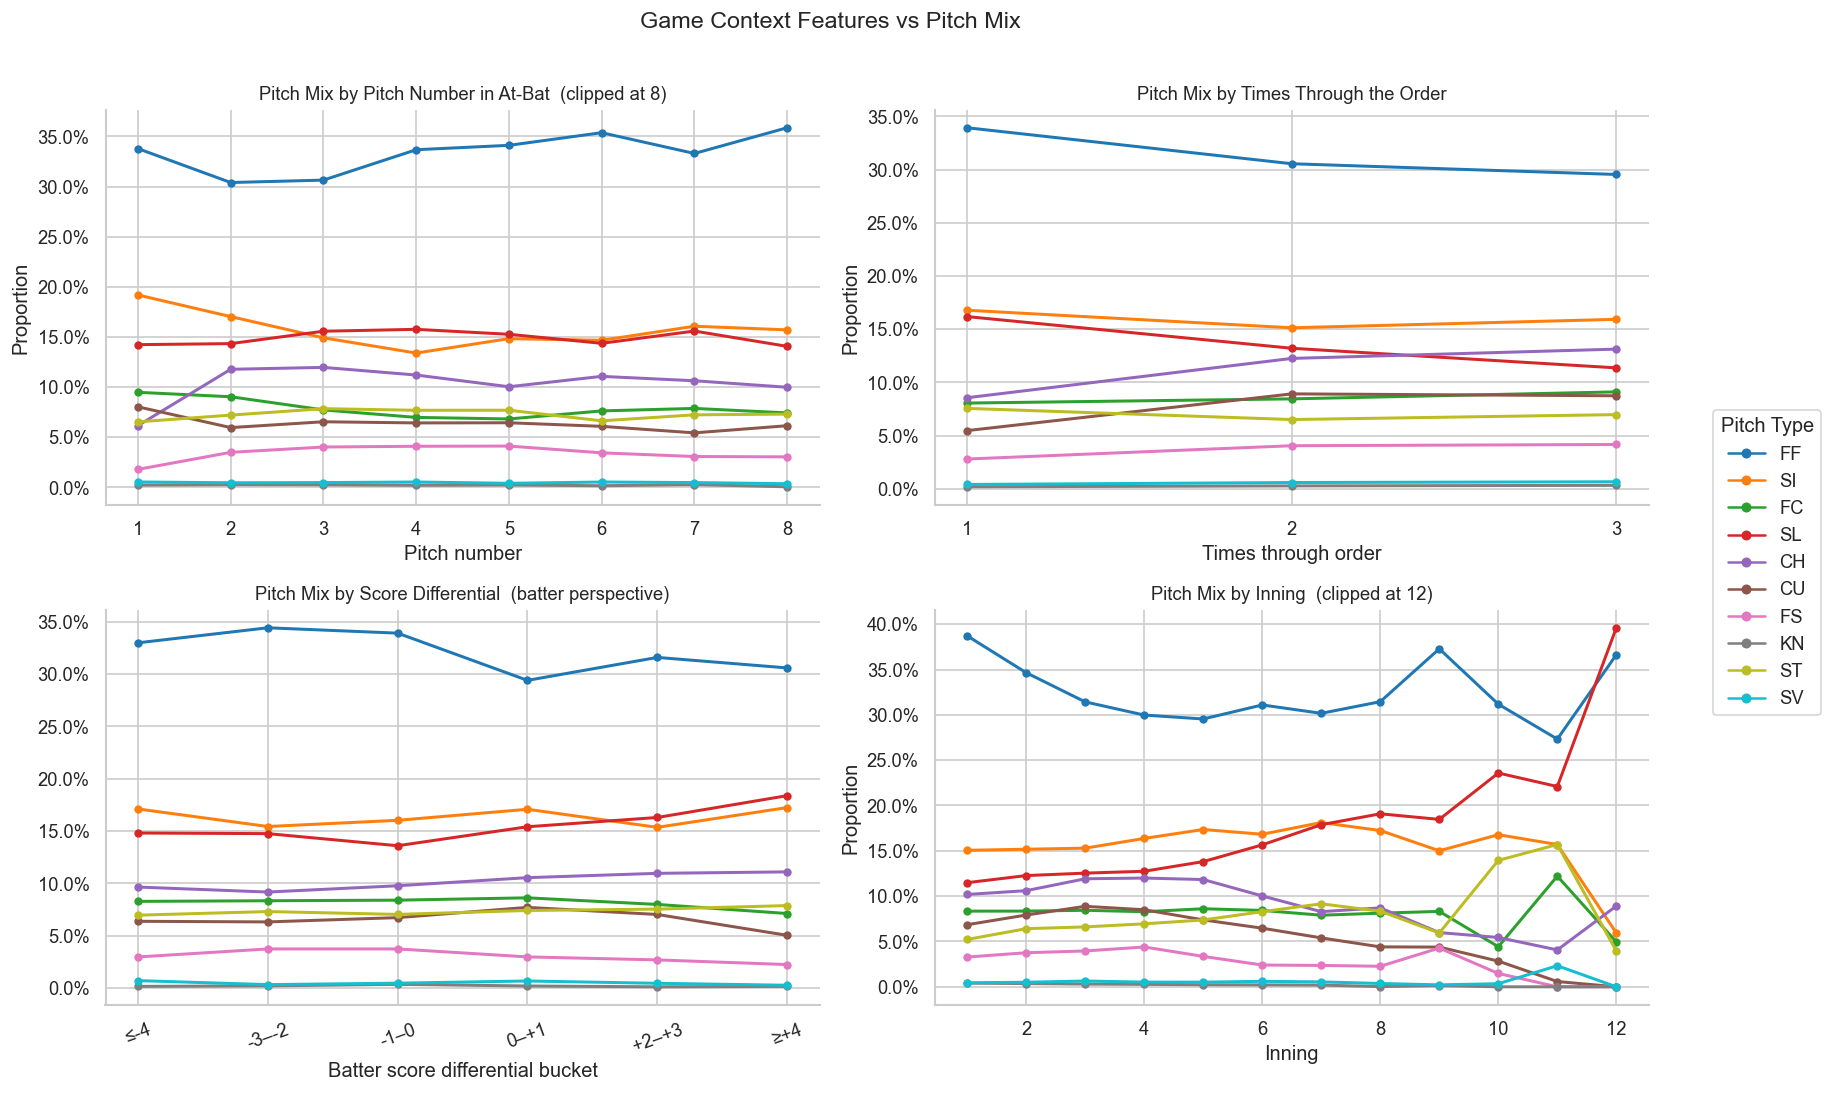

In [16]:
def pitch_mix_line(df, group_col, ax, clip_max=None, title=""):
    """Plot normalised pitch type proportions as lines over a continuous/ordinal group."""
    data = df.copy()
    if clip_max is not None:
        data[group_col] = data[group_col].clip(upper=clip_max)
    mix = (
        data.groupby([group_col, LABEL_COLUMN])
        .size()
        .unstack(fill_value=0)
        .apply(lambda row: row / row.sum(), axis=1)
        .reindex(columns=pt_order, fill_value=0)
    )
    for i, pt in enumerate(pt_order):
        ax.plot(mix.index, mix[pt], marker="o", markersize=4, label=pt,
                color=palette[i], linewidth=1.8)
    ax.set_ylabel("Proportion")
    ax.set_title(title, fontsize=11)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    sns.despine(ax=ax)


fig, axes = plt.subplots(2, 2, figsize=(14, 9))

### pitch_number (clip to 8 to keep sparse tail from dominating)
pitch_mix_line(model_df, "pitch_number", axes[0, 0], clip_max=8,
               title="Pitch Mix by Pitch Number in At-Bat  (clipped at 8)")
axes[0, 0].set_xlabel("Pitch number")

### n_thruorder_pitcher
thru = model_df[model_df["n_thruorder_pitcher"].between(1, 3)].copy()
pitch_mix_line(thru, "n_thruorder_pitcher", axes[0, 1],
               title="Pitch Mix by Times Through the Order")
axes[0, 1].set_xlabel("Times through order")
axes[0, 1].set_xticks([1, 2, 3])

### bat_score_diff (bucketed)
SCORE_BINS   = [-np.inf, -4, -2, 0, 2, 4, np.inf]
SCORE_LABELS = ["≤-4", "-3–-2", "-1–0", "0–+1", "+2–+3", "≥+4"]
model_df["score_bucket"] = pd.cut(
    model_df["bat_score_diff"], bins=SCORE_BINS, labels=SCORE_LABELS
)
score_mix = (
    model_df.groupby(["score_bucket", LABEL_COLUMN], observed=True)
    .size()
    .unstack(fill_value=0)
    .apply(lambda row: row / row.sum(), axis=1)
    .reindex(columns=pt_order, fill_value=0)
)
for i, pt in enumerate(pt_order):
    axes[1, 0].plot(score_mix.index.astype(str), score_mix[pt], marker="o",
                    markersize=4, label=pt, color=palette[i], linewidth=1.8)
axes[1, 0].set_xlabel("Batter score differential bucket")
axes[1, 0].set_title("Pitch Mix by Score Differential  (batter perspective)", fontsize=11)
axes[1, 0].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
axes[1, 0].tick_params(axis="x", rotation=20)
sns.despine(ax=axes[1, 0])

### inning (1–12, clip extras)
pitch_mix_line(model_df, "inning", axes[1, 1], clip_max=12,
               title="Pitch Mix by Inning  (clipped at 12)")
axes[1, 1].set_xlabel("Inning")

handles = [plt.Line2D([0], [0], color=palette[i], marker="o", markersize=5)
           for i in range(len(pt_order))]
fig.legend(handles, pt_order, title="Pitch Type", bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.suptitle("Game Context Features vs Pitch Mix", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()